In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("gpu_database.csv")


In [3]:
df.head()

,model,launch_date,code_name,fab_nm,transistors_million,die_size_mm2,bus_interface,core_clock_mhz,memory_clock_mhz,core_config,processing_power_gflops,tdp_watts,manufacturer
0,STG-2000,1995-09-30 00:00:00.000000000,NV1,SGS 500 nm,1.0,135.0,PCI,75.0,NaN,1:1:1,NaN,NaN,Nvidia
1,NV1,1995-09-30 00:00:00.000000000,NV1,SGS 500 nm,1.0,135.0,PCI,75.0,NaN,1:1:1,NaN,2.0,Nvidia
2,Riva 128,1997-04-01 00:00:00.000000000,NV3,SGS 350 nm,4.0,71.0,AGP 2x,100.0,NaN,1:1:1,NaN,4.0,Nvidia
3,Riva 128,1997-04-01 00:00:00.000000000,NV3,SGS 350 nm,4.0,71.0,PCI,100.0,NaN,1:1:1,NaN,4.0,Nvidia
4,Riva 128ZX,1998-02-23 00:00:00.000000000,NV3,SGS 350 nm,4.0,71.0,AGP 2x,100.0,NaN,1:1:1,NaN,NaN,Nvidia


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1943 entries, 0 to 1942
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   model                    1943 non-null   str    
 1   launch_date              1299 non-null   str    
 2   code_name                1564 non-null   str    
 3   fab_nm                   1655 non-null   str    
 4   transistors_million      942 non-null    float64
 5   die_size_mm2             927 non-null    float64
 6   bus_interface            1691 non-null   str    
 7   core_clock_mhz           1276 non-null   float64
 8   memory_clock_mhz         517 non-null    float64
 9   core_config              1427 non-null   str    
 10  processing_power_gflops  1349 non-null   float64
 11  tdp_watts                1324 non-null   float64
 12  manufacturer             1943 non-null   str    
dtypes: float64(6), str(7)
memory usage: 197.5 KB


In [5]:
df.describe()

,transistors_million,die_size_mm2,core_clock_mhz,memory_clock_mhz,processing_power_gflops,tdp_watts
count,942.000000,927.000000,1276.000000,517.000000,1349.000000,1324.000000
mean,680.824076,404.836688,669.547806,950.578337,1198.153517,95.236631
std,1497.672751,964.552339,423.169505,1043.030991,3088.715086,116.077404
min,1.000000,1.550000,40.000000,40.000000,1.000000,2.000000
25%,13.230000,65.000000,400.000000,350.000000,35.870000,30.000000
50%,146.000000,144.000000,574.500000,650.000000,268.800000,58.000000
75%,666.000000,324.000000,810.000000,1350.000000,949.248000,122.000000
max,21000.000000,8900.000000,2700.000000,10000.000000,55296.000000,1400.000000


In [6]:
df.isnull().sum()

model                         0
launch_date                 644
code_name                   379
fab_nm                      288
transistors_million        1001
die_size_mm2               1016
bus_interface               252
core_clock_mhz              667
memory_clock_mhz           1426
core_config                 516
processing_power_gflops     594
tdp_watts                   619
manufacturer                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['launch_date'] = pd.to_datetime(df['launch_date'], errors='coerce')

In [9]:
df['fab_nm'] = df['fab_nm'].astype(str).str.replace('nm', '')
df[['foundry', 'process_node_nm']] = df['fab_nm'].str.extract(r'([a-zA-Z]+)\s+(\d+)')
df['process_node_nm'] = pd.to_numeric(df['process_node_nm'])
df.drop(columns='fab_nm', inplace=True)

In [10]:
df = df[['model','launch_date','code_name','foundry','process_node_nm',
         'transistors_million','die_size_mm2','bus_interface',
         'core_clock_mhz','memory_clock_mhz','core_config',
         'processing_power_gflops','tdp_watts','manufacturer']]

In [11]:
df.head()

,model,launch_date,code_name,foundry,process_node_nm,transistors_million,die_size_mm2,bus_interface,core_clock_mhz,memory_clock_mhz,core_config,processing_power_gflops,tdp_watts,manufacturer
0,STG-2000,1995-09-30,NV1,SGS,500.0,1.0,135.0,PCI,75.0,NaN,1:1:1,NaN,NaN,Nvidia
1,NV1,1995-09-30,NV1,SGS,500.0,1.0,135.0,PCI,75.0,NaN,1:1:1,NaN,2.0,Nvidia
2,Riva 128,1997-04-01,NV3,SGS,350.0,4.0,71.0,AGP 2x,100.0,NaN,1:1:1,NaN,4.0,Nvidia
3,Riva 128,1997-04-01,NV3,SGS,350.0,4.0,71.0,PCI,100.0,NaN,1:1:1,NaN,4.0,Nvidia
4,Riva 128ZX,1998-02-23,NV3,SGS,350.0,4.0,71.0,AGP 2x,100.0,NaN,1:1:1,NaN,NaN,Nvidia


In [12]:
print("Dataset size:", df.shape)
print("Columns:")
print(list(df.columns))

Dataset size: (1943, 14)
Columns:
['model', 'launch_date', 'code_name', 'foundry', 'process_node_nm', 'transistors_million', 'die_size_mm2', 'bus_interface', 'core_clock_mhz', 'memory_clock_mhz', 'core_config', 'processing_power_gflops', 'tdp_watts', 'manufacturer']


In [13]:
df.describe()

,launch_date,process_node_nm,transistors_million,die_size_mm2,core_clock_mhz,memory_clock_mhz,processing_power_gflops,tdp_watts
count,1299,827.000000,942.000000,927.000000,1276.000000,517.000000,1349.000000,1324.000000
mean,2010-02-05 15:11:13.441108480,38.142684,680.824076,404.836688,669.547806,950.578337,1198.153517,95.236631
min,1970-01-01 00:00:00.000001986,1.000000,1.000000,1.550000,40.000000,40.000000,1.000000,2.000000
25%,2006-01-24 00:00:00,2.000000,13.230000,65.000000,400.000000,350.000000,35.870000,30.000000
50%,2010-01-10 00:00:00,4.000000,146.000000,144.000000,574.500000,650.000000,268.800000,58.000000
75%,2013-11-11 00:00:00,65.000000,666.000000,324.000000,810.000000,1350.000000,949.248000,122.000000
max,2025-08-15 00:00:00,500.000000,21000.000000,8900.000000,2700.000000,10000.000000,55296.000000,1400.000000
std,NaN,58.547172,1497.672751,964.552339,423.169505,1043.030991,3088.715086,116.077404


In [14]:
manufacturer_summary = df.groupby("manufacturer").size()
manufacturer_summary

manufacturer
AMD        891
Nvidia    1052
dtype: int64

In [15]:
top_gpus = df.sort_values(by="processing_power_gflops", ascending=False)
top_gpus.head(10)

,model,launch_date,code_name,foundry,process_node_nm,transistors_million,die_size_mm2,bus_interface,core_clock_mhz,memory_clock_mhz,core_config,processing_power_gflops,tdp_watts,manufacturer
1895,Radeon Pro V710 (Navi 32),NaT,Radeon Pro V710 (Navi 32)[633][634],RDNA,3.0,28.10,28.10,PCIe 4.0 ×16,NaN,NaN,NaN,55296.0,158.0,AMD
1770,Radeon Pro Vega II (Vega 20),NaT,Radeon Pro Vega II (Vega 20)[424][425][426],GCN,5.0,13.23,13.23,PCIe 3.0 ×16,NaN,NaN,NaN,28180.0,NaN,AMD
1679,Radeon RX 6850M XT (Navi 22),NaT,Radeon RX 6850M XT (Navi 22)[312],RDNA,2.0,17.20,17.20,PCIe 4.0 ×16,NaN,NaN,NaN,26430.0,165.0,AMD
1678,Radeon RX 6800M (Navi 22),NaT,Radeon RX 6800M (Navi 22)[311],RDNA,2.0,17.20,17.20,PCIe 4.0 ×16,NaN,NaN,NaN,23550.0,145.0,AMD
1677,Radeon RX 6700M (Navi 22),NaT,Radeon RX 6700M (Navi 22)[310],RDNA,2.0,17.20,17.20,PCIe 4.0 ×16,NaN,NaN,NaN,21209.0,135.0,AMD
1676,Radeon RX 6650M XT (Navi 23),NaT,Radeon RX 6650M XT (Navi 23)[309],RDNA,2.0,11.06,11.06,PCIe 4.0 ×8,NaN,NaN,NaN,19940.0,120.0,AMD
1785,Radeon Pro W6600X (Navi 23),NaT,Radeon Pro W6600X (Navi 23)[450][451][452],RDNA,2.0,11.06,11.06,PCIe 4.0 ×8,NaN,NaN,NaN,19673.0,120.0,AMD
697,GeForce RTX 2080 Super,2020-04-02,TU104,NaN,NaN,13.60,545.00,PCIe 3.0 x16,NaN,NaN,3072:192: 64:384:48 (48) (6),19170.0,150.0,Nvidia
695,GeForce RTX 2080,2019-01-29,TU104,NaN,NaN,13.60,545.00,PCIe 3.0 x16,NaN,NaN,2944:184: 64:368:46 (46) (6),18720.0,150.0,Nvidia
1675,Radeon RX 6800S (Navi 23),NaT,Radeon RX 6800S (Navi 23)[308],RDNA,2.0,11.06,11.06,PCIe 4.0 ×8,NaN,NaN,NaN,18430.0,100.0,AMD


In [16]:
foundry_summary = df["foundry"].value_counts()
foundry_summary

foundry
TSMC         367
GCN          240
TeraScale     75
RDNA          75
Terascale     19
Samsung       18
UMC            8
CDNA           8
IBM            7
SGS            5
NEC            2
Toshiba        1
PCIe           1
Renesas        1
Name: count, dtype: int64

In [17]:
import matplotlib.pyplot as plt

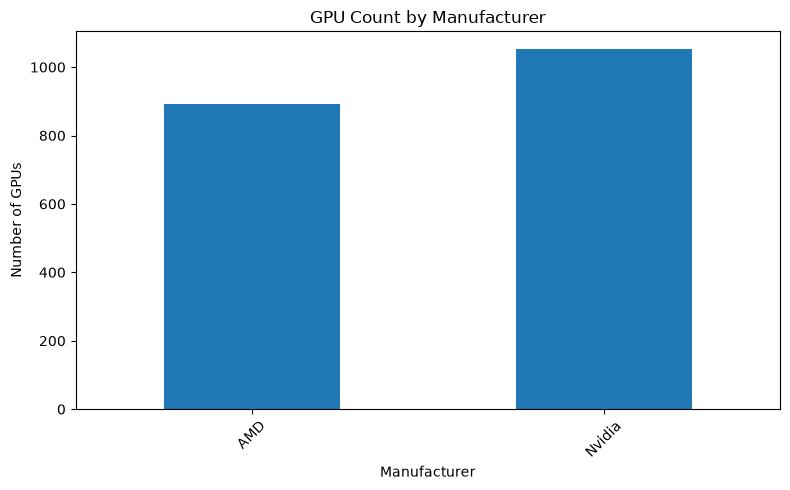

In [18]:
plt.figure(figsize=(8,5))
manufacturer_summary.plot(kind="bar")
plt.xlabel("Manufacturer")
plt.ylabel("Number of GPUs")
plt.title("GPU Count by Manufacturer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

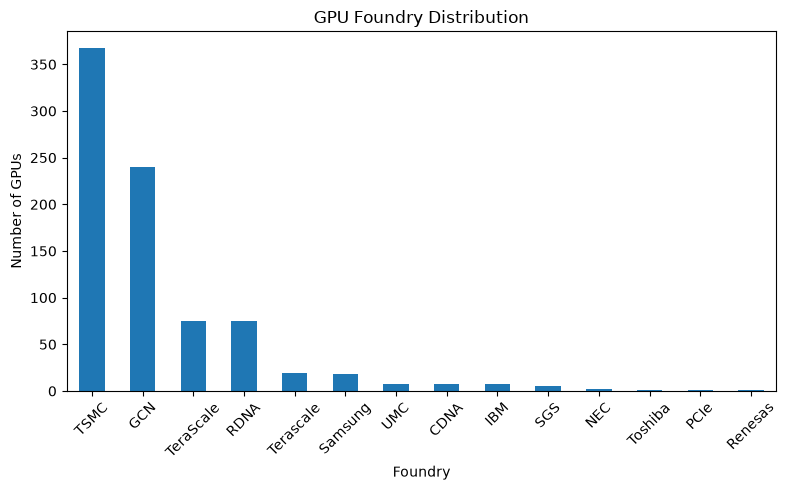

In [19]:
plt.figure(figsize=(8,5))
foundry_summary.plot(kind="bar")
plt.xlabel("Foundry")
plt.ylabel("Number of GPUs")
plt.title("GPU Foundry Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

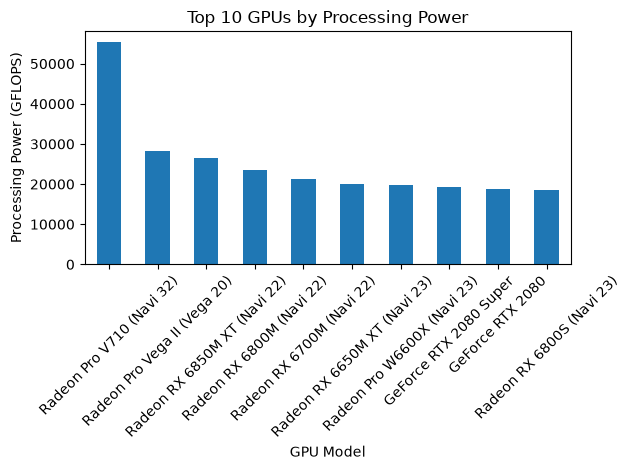

In [20]:
plt.figure(figsize=(10,5))
top_gpus.head(10).plot(x="model", y="processing_power_gflops", kind="bar", legend=False)
plt.xlabel("GPU Model")
plt.ylabel("Processing Power (GFLOPS)")
plt.title("Top 10 GPUs by Processing Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
df.to_csv("cleaned_data.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
